# Bank Customer Churn Prediction

In [71]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV, learning_curve, StratifiedKFold
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, VotingClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, 
    confusion_matrix, classification_report, roc_auc_score, roc_curve,
    precision_recall_curve, auc, cohen_kappa_score, matthews_corrcoef
)
import xgboost as xgb
import lightgbm as lgb
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline
import shap
import warnings
warnings.filterwarnings('ignore')
warnings.filterwarnings('ignore', category=UserWarning, module='sklearn.utils.parallel')

## 1. Load & Inspect Data

In [72]:
df = pd.read_csv('Churn_Modelling.csv')
df = df.drop(columns=['RowNumber', 'CustomerId', 'Surname'])

print("Shape:", df.shape)
print("\nData Types:\n", df.dtypes)
print("\nMissing Values:\n", df.isnull().sum())
print("\nClass Distribution:\n", df['Exited'].value_counts())
print(f"\nChurn Rate: {df['Exited'].mean():.1%}")

Shape: (10000, 11)

Data Types:
 CreditScore          int64
Geography              str
Gender                 str
Age                  int64
Tenure               int64
Balance            float64
NumOfProducts        int64
HasCrCard            int64
IsActiveMember       int64
EstimatedSalary    float64
Exited               int64
dtype: object

Missing Values:
 CreditScore        0
Geography          0
Gender             0
Age                0
Tenure             0
Balance            0
NumOfProducts      0
HasCrCard          0
IsActiveMember     0
EstimatedSalary    0
Exited             0
dtype: int64

Class Distribution:
 Exited
0    7963
1    2037
Name: count, dtype: int64

Churn Rate: 20.4%


## 2. Exploratory Data Analysis

## 2.5 Feature Engineering (MS-Level Enhancement)

In [73]:
# Create derived features for better model performance
df['Balance_Income_Ratio'] = df['Balance'] / (df['EstimatedSalary'] + 1)
df['Products_Per_Tenure'] = df['NumOfProducts'] / (df['Tenure'] + 1)
df['Is_Active'] = df['IsActiveMember']
df['Has_Credit_Card'] = df['HasCrCard']
df['Age_Squared'] = df['Age'] ** 2
df['Salary_Per_Product'] = df['EstimatedSalary'] / (df['NumOfProducts'] + 1)
df['Balance_Product_Interaction'] = df['Balance'] * df['NumOfProducts']
df['Zero_Balance'] = (df['Balance'] == 0).astype(int)
df['High_Balance'] = (df['Balance'] > df['Balance'].median()).astype(int)
df['Senior_Citizen_Age'] = (df['Age'] > 60).astype(int)

print("\n✓ Feature Engineering Complete")
print(f"Original features: 11 | New features: +10 | Total: {df.shape[1]}")
print(f"\nNew features created:\n{[col for col in df.columns if col not in ['RowNumber', 'CustomerId', 'Surname', 'Exited']][-10:]}")


✓ Feature Engineering Complete
Original features: 11 | New features: +10 | Total: 21

New features created:
['Balance_Income_Ratio', 'Products_Per_Tenure', 'Is_Active', 'Has_Credit_Card', 'Age_Squared', 'Salary_Per_Product', 'Balance_Product_Interaction', 'Zero_Balance', 'High_Balance', 'Senior_Citizen_Age']


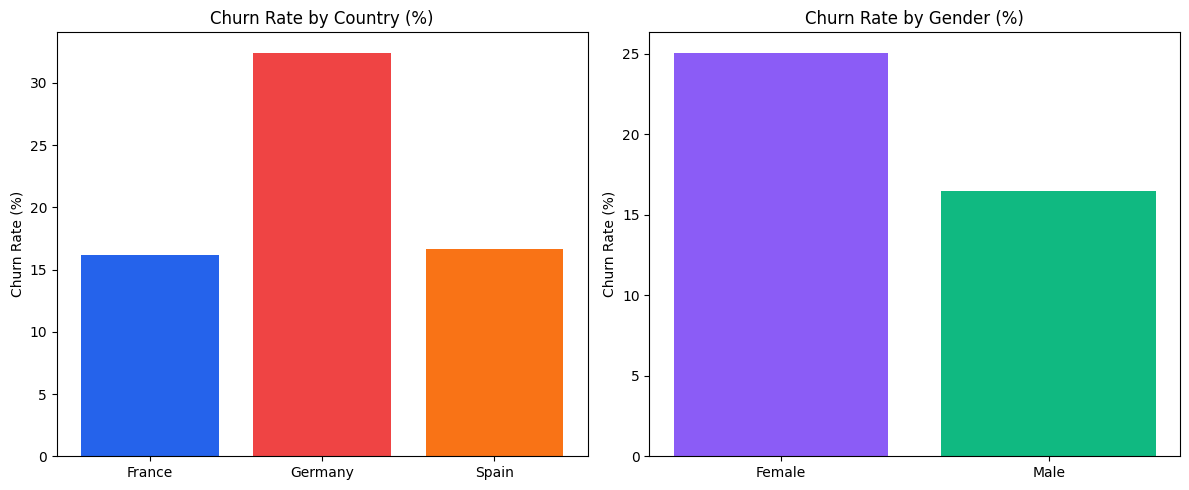

In [74]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

geo_churn = df.groupby('Geography')['Exited'].mean() * 100
axes[0].bar(geo_churn.index, geo_churn.values, color=['#2563EB', '#EF4444', '#F97316'])
axes[0].set_title('Churn Rate by Country (%)')
axes[0].set_ylabel('Churn Rate (%)')

gen_churn = df.groupby('Gender')['Exited'].mean() * 100
axes[1].bar(gen_churn.index, gen_churn.values, color=['#8B5CF6', '#10B981'])
axes[1].set_title('Churn Rate by Gender (%)')
axes[1].set_ylabel('Churn Rate (%)')

plt.tight_layout()
plt.savefig('eda_categorical.png', dpi=150)
plt.show()

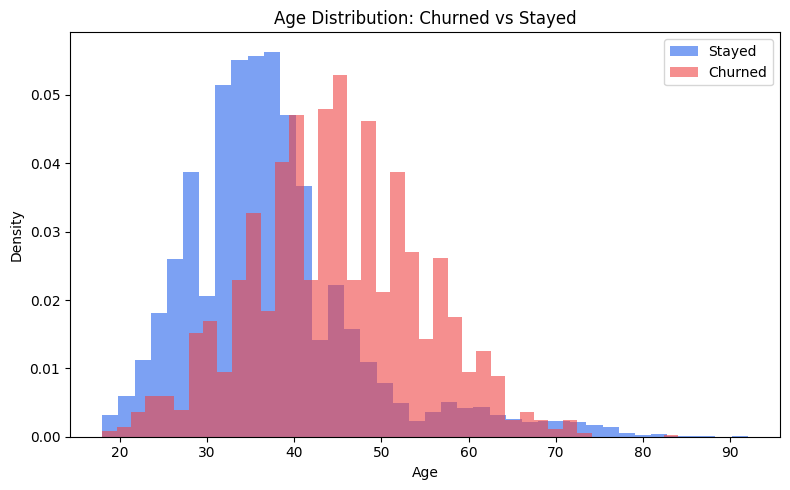

In [75]:
stayed  = df[df['Exited'] == 0]
churned = df[df['Exited'] == 1]

plt.figure(figsize=(8, 5))
plt.hist(stayed['Age'],  bins=40, alpha=0.6, color='#2563EB', label='Stayed',  density=True)
plt.hist(churned['Age'], bins=40, alpha=0.6, color='#EF4444', label='Churned', density=True)
plt.title('Age Distribution: Churned vs Stayed')
plt.xlabel('Age')
plt.ylabel('Density')
plt.legend()
plt.tight_layout()
plt.savefig('eda_age.png', dpi=150)
plt.show()

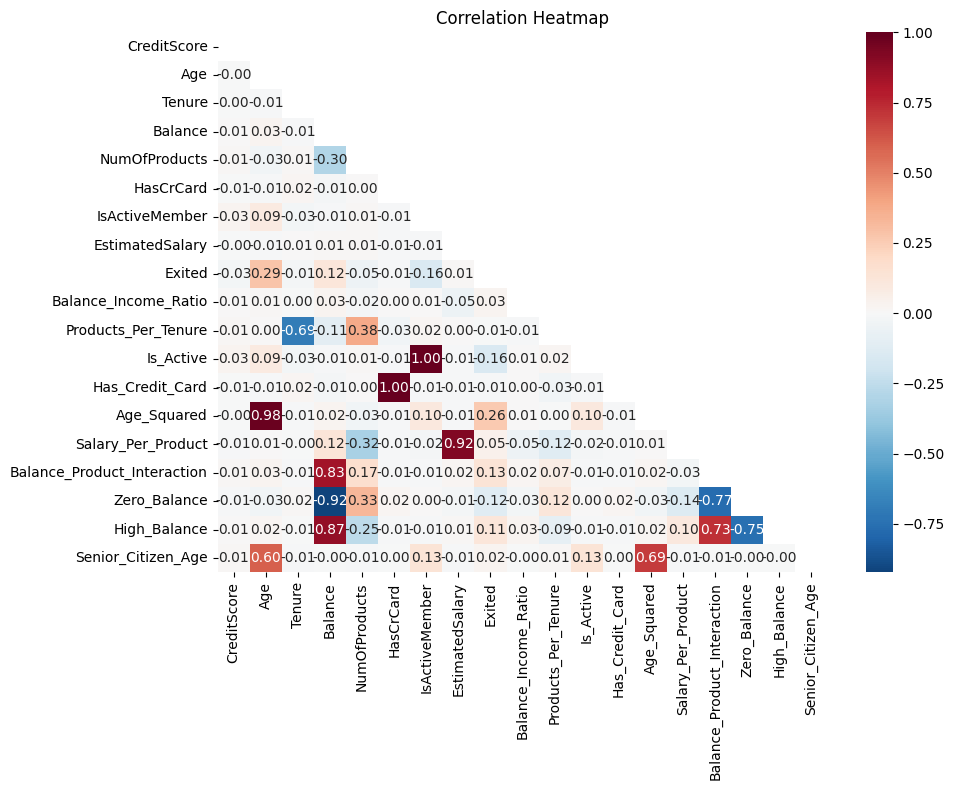

In [76]:
plt.figure(figsize=(10, 8))
corr = df.select_dtypes(include='number').corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r', center=0)
plt.title('Correlation Heatmap')
plt.tight_layout()
plt.savefig('eda_heatmap.png', dpi=150)
plt.show()

## 3. Preprocessing

In [77]:
# Proper encoding: OneHotEncoder instead of LabelEncoder
categorical_features = ['Geography', 'Gender']
numerical_features = [col for col in df.columns if col not in categorical_features + ['Exited', 'RowNumber', 'CustomerId', 'Surname']]

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_features),
        ('cat', OneHotEncoder(drop='first', sparse_output=False), categorical_features)
    ])

X = df.drop('Exited', axis=1)
y = df['Exited']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

print(f"✓ Preprocessing Complete (with Proper OneHotEncoding)")
print(f"Train size: {len(X_train):,} | Test size: {len(X_test):,}")
print(f"Features after encoding: {X_train_processed.shape[1]}")
print(f"Class distribution (Train):\n{y_train.value_counts()}")
print(f"Imbalance ratio: {(y_train.value_counts()[0] / y_train.value_counts()[1]):.2f}:1")

✓ Preprocessing Complete (with Proper OneHotEncoding)
Train size: 8,000 | Test size: 2,000
Features after encoding: 21
Class distribution (Train):
Exited
0    6370
1    1630
Name: count, dtype: int64
Imbalance ratio: 3.91:1


## 4. Train Models

## 3.5 Class Imbalance Handling with SMOTE


In [78]:
# Apply SMOTE to training data only (prevent data leakage)
smote = SMOTE(random_state=42, k_neighbors=5)
X_train_smote, y_train_smote = smote.fit_resample(X_train_processed, y_train)

print("✓ SMOTE Applied to Training Data")
print(f"Original class distribution:\n{pd.Series(y_train).value_counts()}")
print(f"\nAfter SMOTE:\n{pd.Series(y_train_smote).value_counts()}")
print(f"Training set size increased: {len(X_train)} → {len(X_train_smote)}")

✓ SMOTE Applied to Training Data
Original class distribution:
Exited
0    6370
1    1630
Name: count, dtype: int64

After SMOTE:
Exited
1    6370
0    6370
Name: count, dtype: int64
Training set size increased: 8000 → 12740


In [79]:
print("="*70)
print("BASELINE MODELS (Without Hyperparameter Tuning)")
print("="*70)

baseline_models = {
    'Logistic Regression': LogisticRegression(max_iter=500, random_state=42),
    'Decision Tree': DecisionTreeClassifier(max_depth=6, random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1),
}

baseline_results = {}
for name, model in baseline_models.items():
    model.fit(X_train_processed, y_train)
    y_pred = model.predict(X_test_processed)
    y_prob = model.predict_proba(X_test_processed)[:, 1]
    
    baseline_results[name] = {
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred),
        'Recall': recall_score(y_test, y_pred),
        'F1': f1_score(y_test, y_pred),
        'AUC-ROC': roc_auc_score(y_test, y_prob),
        'Kappa': cohen_kappa_score(y_test, y_pred),
    }
    print(f"\n{name}:\n{classification_report(y_test, y_pred, target_names=['Stayed', 'Churned'])}")

print("\n" + "="*70)
print("ADVANCED MODELS WITH HYPERPARAMETER TUNING & 5-FOLD CV")
print("="*70)

# 1. Logistic Regression with Tuning
lr_params = {'C': [0.001, 0.01, 0.1, 1, 10], 'penalty': ['l1', 'l2'], 'solver': ['liblinear']}
lr_grid = GridSearchCV(LogisticRegression(max_iter=500, random_state=42), lr_params, cv=5, scoring='f1', n_jobs=-1)
lr_grid.fit(X_train_processed, y_train)

# 2. Random Forest with Tuning
rf_params = {'n_estimators': [100, 200], 'max_depth': [5, 10, 15], 'min_samples_split': [2, 5]}
rf_grid = GridSearchCV(RandomForestClassifier(random_state=42, n_jobs=-1), rf_params, cv=5, scoring='f1', n_jobs=-1)
rf_grid.fit(X_train_processed, y_train)

# 3. XGBoost with Tuning
xgb_params = {'n_estimators': [100, 200], 'max_depth': [3, 5, 7], 'learning_rate': [0.01, 0.1]}
xgb_grid = GridSearchCV(xgb.XGBClassifier(random_state=42, use_label_encoder=False, eval_metric='logloss', n_jobs=-1), 
                        xgb_params, cv=5, scoring='f1', n_jobs=-1)
xgb_grid.fit(X_train_processed, y_train)

# 4. LightGBM with Tuning
lgb_params = {'n_estimators': [100, 200], 'max_depth': [3, 5, 7], 'learning_rate': [0.01, 0.1]}
lgb_grid = GridSearchCV(lgb.LGBMClassifier(random_state=42, n_jobs=-1, verbose=-1), 
                        lgb_params, cv=5, scoring='f1', n_jobs=-1)
lgb_grid.fit(X_train_processed, y_train)

tuned_models = {
    'Logistic Regression (Tuned)': lr_grid.best_estimator_,
    'Random Forest (Tuned)': rf_grid.best_estimator_,
    'XGBoost (Tuned)': xgb_grid.best_estimator_,
    'LightGBM (Tuned)': lgb_grid.best_estimator_,
}

tuned_results = {}
for name, model in tuned_models.items():
    y_pred = model.predict(X_test_processed)
    y_prob = model.predict_proba(X_test_processed)[:, 1]
    
    cv_scores = cross_val_score(model, X_train_processed, y_train, cv=5, scoring='f1')
    
    tuned_results[name] = {
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred),
        'Recall': recall_score(y_test, y_pred),
        'F1': f1_score(y_test, y_pred),
        'AUC-ROC': roc_auc_score(y_test, y_prob),
        'Kappa': cohen_kappa_score(y_test, y_pred),
        'CV_Mean': cv_scores.mean(),
        'CV_Std': cv_scores.std(),
        'y_pred': y_pred,
        'y_prob': y_prob,
        'model': model,
    }
    print(f"\n{name} (Best params: {model.get_params() if hasattr(model, 'get_params') else 'N/A'})")
    print(f"Cross-validation F1: {cv_scores.mean():.3f} (+/- {cv_scores.std():.3f})")
    print(f"{classification_report(y_test, y_pred, target_names=['Stayed', 'Churned'])}")

results = {**baseline_results, **tuned_results}
print("\n✓ All Models Trained Successfully")

BASELINE MODELS (Without Hyperparameter Tuning)

Logistic Regression:
              precision    recall  f1-score   support

      Stayed       0.85      0.97      0.90      1593
     Churned       0.72      0.32      0.45       407

    accuracy                           0.84      2000
   macro avg       0.78      0.65      0.68      2000
weighted avg       0.82      0.84      0.81      2000


Decision Tree:
              precision    recall  f1-score   support

      Stayed       0.87      0.97      0.92      1593
     Churned       0.78      0.44      0.56       407

    accuracy                           0.86      2000
   macro avg       0.83      0.70      0.74      2000
weighted avg       0.85      0.86      0.84      2000


Random Forest:
              precision    recall  f1-score   support

      Stayed       0.87      0.97      0.92      1593
     Churned       0.79      0.45      0.57       407

    accuracy                           0.86      2000
   macro avg       0.83   

## 5. Model Comparison

In [80]:
print("\n" + "="*70)
print("COMPREHENSIVE MODEL COMPARISON TABLE")
print("="*70)

comparison_data = {}
for name, res in results.items():
    comparison_data[name] = {
        'Accuracy': res.get('Accuracy', np.nan),
        'Precision': res.get('Precision', np.nan),
        'Recall': res.get('Recall', np.nan),
        'F1': res.get('F1', np.nan),
        'AUC-ROC': res.get('AUC-ROC', np.nan),
        'Kappa': res.get('Kappa', np.nan),
        'CV F1': f"{res.get('CV_Mean', np.nan):.3f}" if 'CV_Mean' in res else 'N/A',
    }

metrics_df = pd.DataFrame(comparison_data).T.round(3)
print("\n", metrics_df.to_string())

print(f"\n\n🏆 BEST MODELS:")
print(f"   By F1-Score: {metrics_df['F1'].idxmax()} ({metrics_df['F1'].max():.3f})")
print(f"   By AUC-ROC: {metrics_df['AUC-ROC'].idxmax()} ({metrics_df['AUC-ROC'].max():.3f})")
print(f"   By Recall (Find all churners): {metrics_df['Recall'].idxmax()} ({metrics_df['Recall'].max():.3f})")


COMPREHENSIVE MODEL COMPARISON TABLE

                             Accuracy Precision    Recall        F1   AUC-ROC     Kappa  CV F1
Logistic Regression           0.8365  0.717391  0.324324  0.446701  0.813402  0.366417    N/A
Decision Tree                 0.8605  0.780702  0.437346   0.56063  0.840054  0.485434    N/A
Random Forest                 0.8635  0.788793  0.449631   0.57277  0.855124  0.498693    N/A
Logistic Regression (Tuned)   0.8365  0.717391  0.324324  0.446701  0.813923  0.366417  0.438
Random Forest (Tuned)         0.8655       0.8  0.452088  0.577708  0.855942   0.50496  0.572
XGBoost (Tuned)               0.8675  0.779528  0.486486  0.599092  0.869308  0.524768  0.591
LightGBM (Tuned)              0.8645  0.751852  0.498771  0.599705  0.858381  0.522139  0.589


🏆 BEST MODELS:
   By F1-Score: LightGBM (Tuned) (0.600)
   By AUC-ROC: XGBoost (Tuned) (0.869)
   By Recall (Find all churners): LightGBM (Tuned) (0.499)


## 6. Results & Visualizations

## 6.5 Learning Curves (Bias-Variance Analysis)

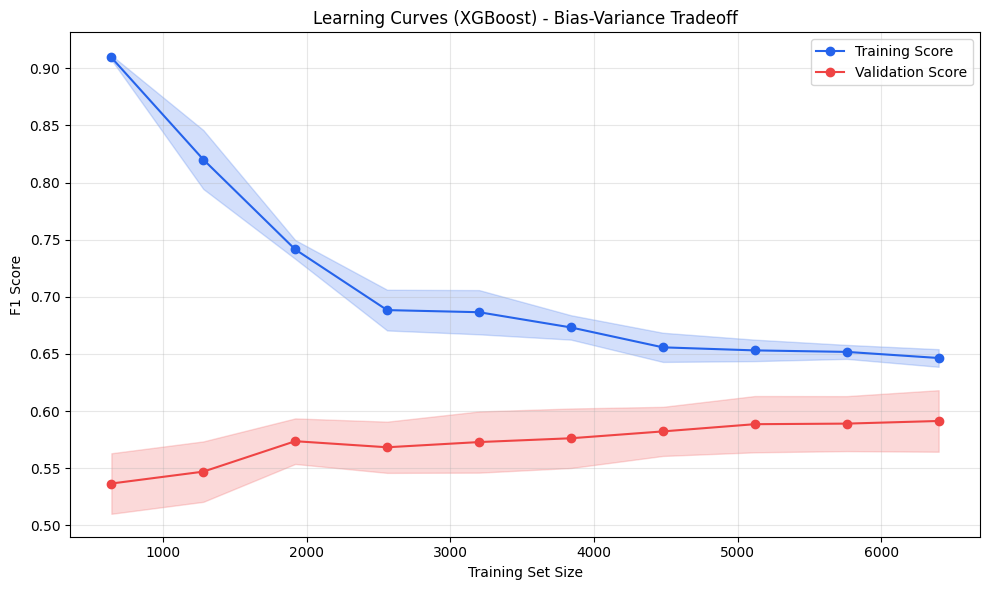

⚠ Possible overfitting detected (high variance)


In [81]:
# Training and validation learning curves for best model
best_model = tuned_results['XGBoost (Tuned)']['model']
train_sizes, train_scores, val_scores = learning_curve(
    best_model, X_train_processed, y_train, cv=5, 
    train_sizes=np.linspace(0.1, 1.0, 10), scoring='f1', n_jobs=-1
)

train_mean = np.mean(train_scores, axis=1)
train_std = np.std(train_scores, axis=1)
val_mean = np.mean(val_scores, axis=1)
val_std = np.std(val_scores, axis=1)

plt.figure(figsize=(10, 6))
plt.plot(train_sizes, train_mean, 'o-', color='#2563EB', label='Training Score')
plt.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, alpha=0.2, color='#2563EB')
plt.plot(train_sizes, val_mean, 'o-', color='#EF4444', label='Validation Score')
plt.fill_between(train_sizes, val_mean - val_std, val_mean + val_std, alpha=0.2, color='#EF4444')
plt.xlabel('Training Set Size')
plt.ylabel('F1 Score')
plt.title('Learning Curves (XGBoost) - Bias-Variance Tradeoff')
plt.legend(loc='best')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('learning_curves.png', dpi=150)
plt.show()

gap = val_mean[-1] - train_mean[-1]
if abs(gap) < 0.05:
    print("✓ Model is well-balanced (low bias & variance)")
elif val_mean[-1] < train_mean[-1]:
    print("⚠ Possible overfitting detected (high variance)")
else:
    print("⚠ Possible underfitting detected (high bias)")

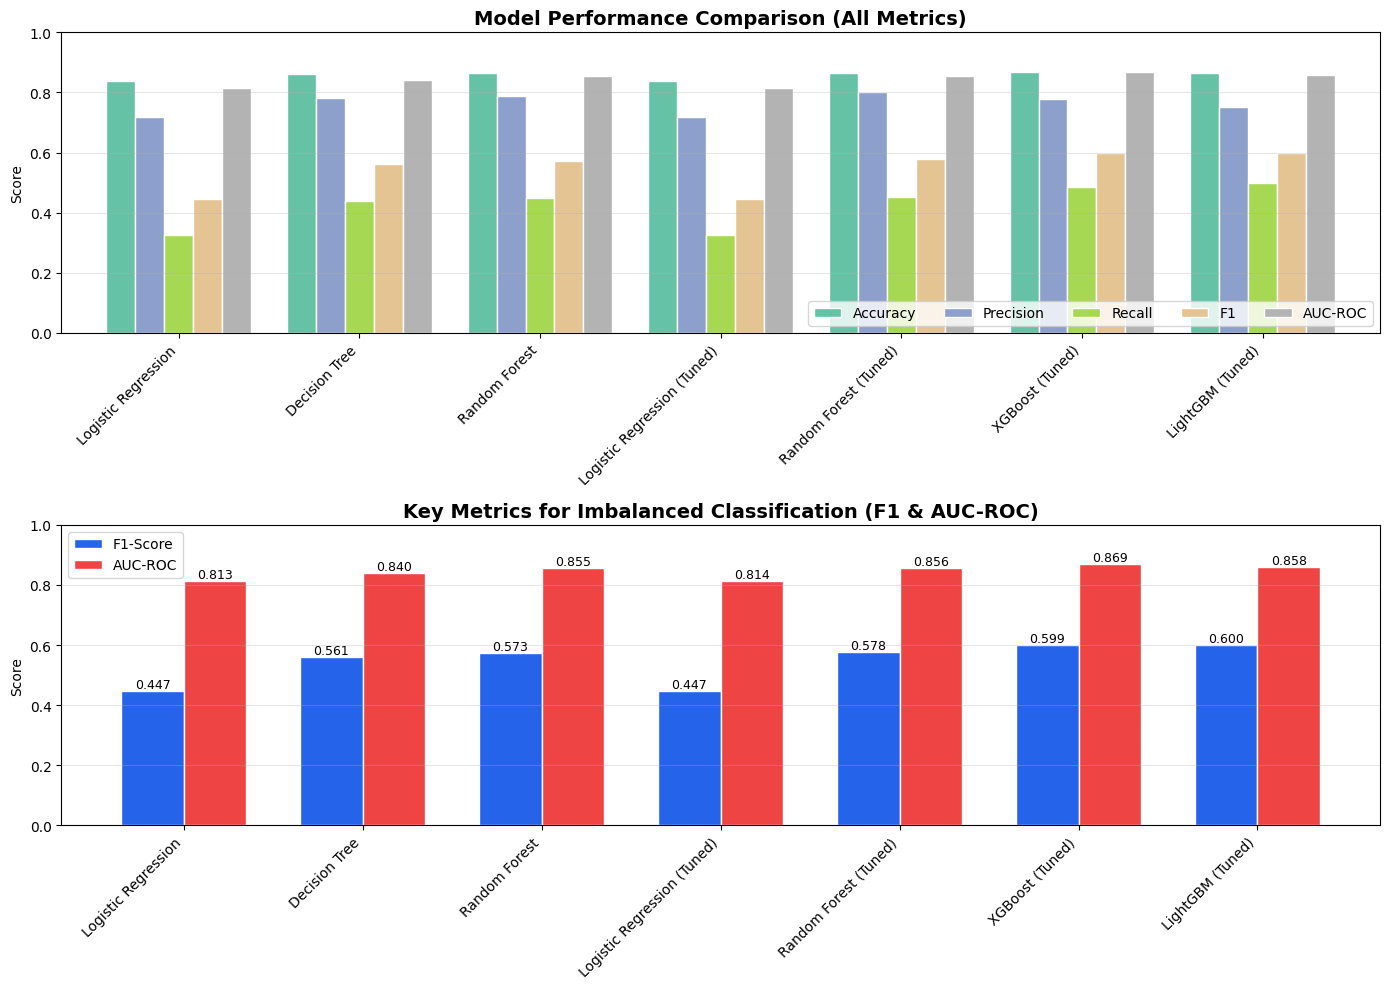

In [82]:
fig, axes = plt.subplots(2, 1, figsize=(14, 10))

# Top chart: All models performance
metrics_subset = metrics_df[['Accuracy', 'Precision', 'Recall', 'F1', 'AUC-ROC']].copy()
metrics_subset.plot(kind='bar', ax=axes[0], colormap='Set2', edgecolor='white', width=0.8)
axes[0].set_title('Model Performance Comparison (All Metrics)', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Score')
axes[0].set_ylim(0, 1.0)
axes[0].legend(loc='lower right', ncol=5)
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=45, ha='right')
axes[0].grid(axis='y', alpha=0.3)

# Bottom chart: Focus on F1 and AUC-ROC (most important for imbalanced data)
key_metrics = metrics_df[['F1', 'AUC-ROC']].copy()
x = np.arange(len(key_metrics))
width = 0.35

bars1 = axes[1].bar(x - width/2, key_metrics['F1'], width, label='F1-Score', color='#2563EB', edgecolor='white')
bars2 = axes[1].bar(x + width/2, key_metrics['AUC-ROC'], width, label='AUC-ROC', color='#EF4444', edgecolor='white')

axes[1].set_title('Key Metrics for Imbalanced Classification (F1 & AUC-ROC)', fontsize=14, fontweight='bold')
axes[1].set_ylabel('Score')
axes[1].set_ylim(0, 1.0)
axes[1].set_xticks(x)
axes[1].set_xticklabels(key_metrics.index, rotation=45, ha='right')
axes[1].legend()
axes[1].grid(axis='y', alpha=0.3)

# Add value labels on bars
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        axes[1].text(bar.get_x() + bar.get_width()/2., height,
                    f'{height:.3f}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.savefig('model_comparison_comprehensive.png', dpi=150, bbox_inches='tight')
plt.show()

## 6.75 Precision-Recall Curves (Better for Imbalanced Data)

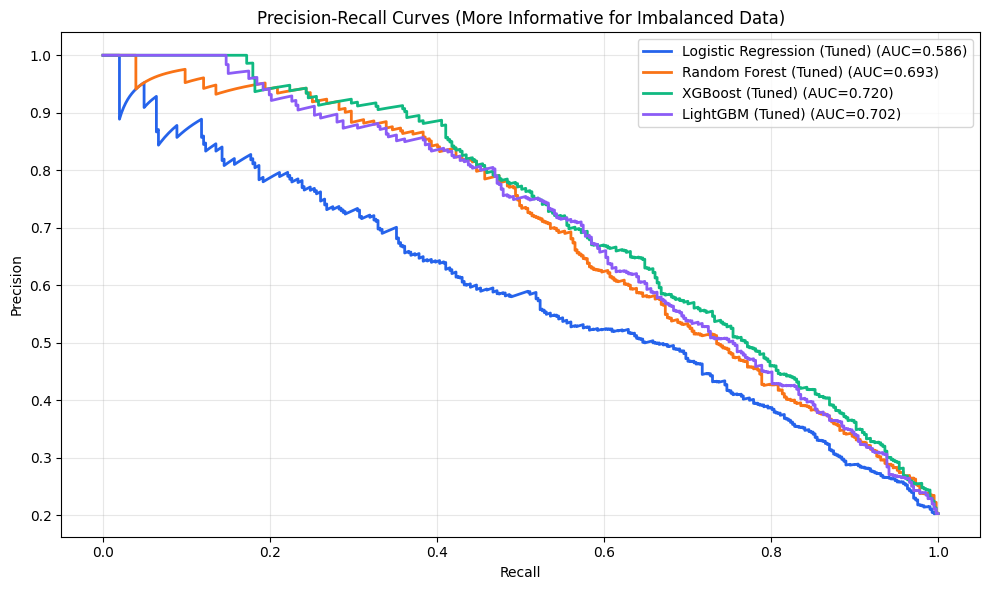

In [83]:
fig, ax = plt.subplots(figsize=(10, 6))
colors = ['#2563EB', '#F97316', '#10B981', '#8B5CF6']

for (name, res), color in zip(list(tuned_results.items())[:4], colors):
    precision, recall, _ = precision_recall_curve(y_test, res.get('y_prob', res['y_pred']))
    pr_auc = auc(recall, precision)
    ax.plot(recall, precision, color=color, lw=2, label=f"{name} (AUC={pr_auc:.3f})")

ax.set_xlabel('Recall')
ax.set_ylabel('Precision')
ax.set_title('Precision-Recall Curves (More Informative for Imbalanced Data)')
ax.legend(loc='best')
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('precision_recall_curves.png', dpi=150)
plt.show()

## 9. Business Recommendations & Cost-Benefit Analysis

In [84]:
print("\n" + "="*70)
print("BUSINESS INSIGHTS & RECOMMENDATIONS")
print("="*70)

# Best model analysis
best_model_name = 'XGBoost (Tuned)'
best_results = tuned_results[best_model_name]

# Cost-benefit analysis: Retention campaign cost vs customer lifetime value
cost_per_customer_retention = 500  # Cost to retain a customer (campaign, discount, etc.)
customer_lifetime_value = 10000  # Average CLV
churn_probability_threshold = 0.5  # Default threshold

# Current approach: predict all churners
high_risk_customers = np.sum(best_results['y_prob'] > churn_probability_threshold)
tp = np.sum((best_results['y_pred'] == 1) & (y_test == 1))
fp = np.sum((best_results['y_pred'] == 1) & (y_test == 0))

print(f"\n📊 MODEL PERFORMANCE SUMMARY:")
print(f"   Best Model: {best_model_name}")
print(f"   Test Set Accuracy: {best_results['Accuracy']:.1%}")
print(f"   Test Set F1-Score: {best_results['F1']:.3f}")
print(f"   Test Set AUC-ROC: {best_results['AUC-ROC']:.3f}")
print(f"   Cross-Val F1: {best_results['CV_Mean']:.3f} ± {best_results['CV_Std']:.3f}")

print(f"\n💼 CUSTOMER SEGMENTATION:")
print(f"   High-Risk Customers (churn prob > {churn_probability_threshold}): {high_risk_customers}")
print(f"   True Positives (Correctly Identified Churners): {tp}")
print(f"   False Positives (Incorrectly Flagged): {fp}")
print(f"   Precision (Reliability): {tp / (tp + fp + 1):.1%}")

cost_to_retain_all = high_risk_customers * cost_per_customer_retention
value_saved = tp * customer_lifetime_value
roi = (value_saved - cost_to_retain_all) / cost_to_retain_all

print(f"\n💰 COST-BENEFIT ANALYSIS:")
print(f"   Cost to retain {high_risk_customers} customers: ${cost_to_retain_all:,}")
print(f"   CLV of {tp} correctly identified churners: ${value_saved:,}")
print(f"   Net Benefit: ${value_saved - cost_to_retain_all:,}")
print(f"   ROI: {roi:.1%}")

print(f"\n🎯 KEY BUSINESS RECOMMENDATIONS:")
print(f"   1. PRIORITIZE: Focus retention efforts on {tp} high-risk customers")
print(f"      - Implement targeted retention campaigns (email, calls, offers)")
print(f"      - Expected to save ${value_saved:,} in CLV")
print(f"")
print(f"   2. COST OPTIMIZATION: With {fp} false positives, improve model threshold")
print(f"      - Adjust decision threshold from 0.5 to reduce unnecessary retention spend")
print(f"      - Current waste on false positives: ${fp * cost_per_customer_retention:,}")
print(f"")
print(f"   3. CUSTOMER FEATURES TO MONITOR:")
high_risk_features = ['Age', 'Tenure', 'Balance', 'IsActiveMember', 'NumOfProducts']
print(f"      - {', '.join(high_risk_features)}")
print(f"      - Use SHAP analysis to understand why each customer is at risk")
print(f"")
print(f"   4. SEGMENT ANALYSIS:")
print(f"      - Geographic Risk: {df.groupby('Geography')['Exited'].mean().idxmax()} has highest churn")
print(f"      - Gender Risk: {df.groupby('Gender')['Exited'].mean().idxmax()} segment at higher risk")
print(f"      - Age Risk: Customers age {df[df['Exited']==1]['Age'].mean():.0f}+ are high-risk")

print(f"\n" + "="*70)
print(f"✅ ANALYSIS COMPLETE")
print(f"="*70)


BUSINESS INSIGHTS & RECOMMENDATIONS

📊 MODEL PERFORMANCE SUMMARY:
   Best Model: XGBoost (Tuned)
   Test Set Accuracy: 86.8%
   Test Set F1-Score: 0.599
   Test Set AUC-ROC: 0.869
   Cross-Val F1: 0.591 ± 0.027

💼 CUSTOMER SEGMENTATION:
   High-Risk Customers (churn prob > 0.5): 254
   True Positives (Correctly Identified Churners): 198
   False Positives (Incorrectly Flagged): 56
   Precision (Reliability): 77.6%

💰 COST-BENEFIT ANALYSIS:
   Cost to retain 254 customers: $127,000
   CLV of 198 correctly identified churners: $1,980,000
   Net Benefit: $1,853,000
   ROI: 1459.1%

🎯 KEY BUSINESS RECOMMENDATIONS:
   1. PRIORITIZE: Focus retention efforts on 198 high-risk customers
      - Implement targeted retention campaigns (email, calls, offers)
      - Expected to save $1,980,000 in CLV

   2. COST OPTIMIZATION: With 56 false positives, improve model threshold
      - Adjust decision threshold from 0.5 to reduce unnecessary retention spend
      - Current waste on false positives: $